<a href="https://colab.research.google.com/github/Alex-Devoid/st554-HW5/blob/main/st554_HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW5 — Bias in data and models; SQL Practice.

Name: Alex Devoid  
Course: ST 554 (Spring 2026)

## Part I — Five V’s of Big Data


### 1.
Parcel-level tax / assessor data

We can think about this data using the “Five V’s” framing:
- **Volume**: number of parcels can be huge, especially if we were to aggregate them across the nation.
- **Velocity**: updates arrive on different cadences, like annual reassessment, general sales activity and re-zoning.
- **Variety**: Fields include tax roll info, spatial geometry, sales records, zoning codes, address strings
- **Veracity**: missing/outdated owner names, inconsistent addresses, partial sales data and miscoded land use.
- **Value**: once cleaned we can measure property tax contributions, model change over time, identify inequities, and support community planning.

### 2.

### CRUD - Create, Read, Update, Delete

### **Create**: add new records
```sql
INSERT INTO People(playerID, nameFirst, nameLast)
VALUES ('adevoid01', 'Alex', 'Devoid');
```

### **Read**: query existing records
```sql
SELECT playerID, nameFirst, nameLast
FROM People
WHERE nameLast = 'Devoid';
```

### **Update**: edit records
```sql
UPDATE People
SET nameFirst = 'Al'
WHERE playerID = 'alDevoid01';
```

### **Delete** removes records
```sql
DELETE FROM People
WHERE playerID = 'alDevoid01';
```

### 3.
The `HAVING` clause is used to filter results after an aggregation step like `GROUP BY`.


# Part II — Simulation of a Sampling Distribution



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [4]:
# Simulation settings
# using Seeded random number generator
rng = np.random.default_rng(554)

# sample size
n = 50
# number of simulations
B = 2000
# the “true” intercept used to generate y
beta0_true = 2.0
# the “true” slope used to generate y, how much y changes when x increases by 1.
beta1_true = 0.5
# larger sigma would mean more scattering around the true line
sigma = 2.0

In [5]:
# repeatedly simulate (x, y) then fit slope
slopes = np.empty(B, dtype=float)

for b in range(B):
    x = rng.normal(loc=0.0, scale=1.0, size=n)
    eps = rng.normal(loc=0.0, scale=sigma, size=n)
    y = beta0_true + beta1_true * x + eps

    # closed-form slope
    xbar = x.mean()
    ybar = y.mean()
    b1_hat = np.sum((x - xbar) * (y - ybar)) / np.sum((x - xbar) ** 2)
    slopes[b] = b1_hat

slopes.mean(), slopes.std(ddof=1)

(np.float64(0.49352790518720574), np.float64(0.29008119717166986))

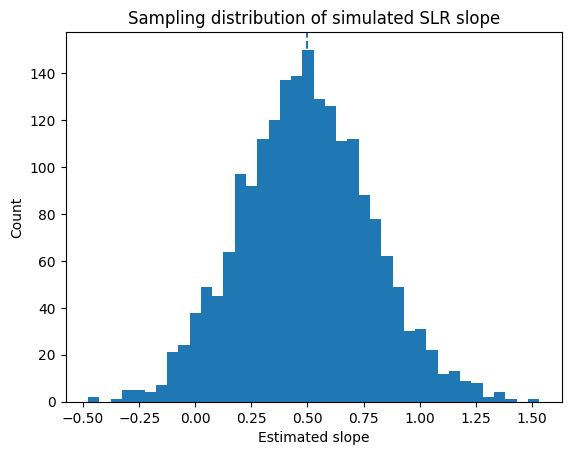

In [6]:
# taking a look at the sampling distribution
plt.figure()
plt.hist(slopes, bins=40)
plt.axvline(beta1_true, linestyle="--")
plt.title("Sampling distribution of simulated SLR slope")
plt.xlabel("Estimated slope")
plt.ylabel("Count")
plt.show()

In [7]:
# Approximate P(sample slope > 1.65)
prob_gt_165 = float(np.mean(slopes > 1.65))
print("Approx P(slope_hat > 1.65):", prob_gt_165)

Approx P(slope_hat > 1.65): 0.0


### Interpretation of Approx P(slope_hat > 1.65)

In this simulation, the estimated probability of getting a sample slope larger than 1.65 was 0.0.  
That happened because none of the simulated slope estimates were greater than 1.65.

This does not mean that the true probablity is 0. It means that under the simulation settings, seeing a slope estimate above 1.65 is extremely unlikely, as we can see in the histogram.   

## Part III — Big Data Examples & Rare Events

### 5.
### Biases in ML models (ICRC article)
**Example bias issue from the article:**  
When the training data reflects unequal coverage or unequal reporting, the model learns patterns that are “true in the dataset” but not fair or valid in the real world.

For example if something like violent crimes are more frequently documented in some areas or groups than others, an Statistical Learning system trained on those records will over-represent those area or groups regions in predictions.

**How to augment / account for bias:**  
- We can augment with additional data sources. For example, we could cover under-reported areas or groups with data from data collected by a third party like an NGO. We could also search for other channels in which a violent crime could have been reported and documented outside triage that built our initial data.
- We can model uncertainty or missingness explicitly by treating observations as “observed events” not “all events,” and be cautious about interpreting absence as zero.
- We can conduct a stratified evaluation by checking model error rates separately by area or group to see if performance is uneven.
- Use a model's prediction as supporting evidence but not proof.

Generally speaking, if the collection process is biased, you can’t fix it just by “better modeling.” We can either either improve the data, or you design the analysis to reflect data limitations.
